In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [2]:
# 데이터 불러오기
data_path = Path('A_DeviceMotion_data 복사본/HAR_total.pkl')
har_total = pd.read_pickle(data_path).copy()

# magnitude가 없으면 생성
if 'magrotationRate' not in har_total.columns:
    har_total['magrotationRate'] = np.sqrt(
        har_total['rotationRate.x'] ** 2
        + har_total['rotationRate.y'] ** 2
        + har_total['rotationRate.z'] ** 2
    )

if 'maguserAcceleration' not in har_total.columns:
    har_total['maguserAcceleration'] = np.sqrt(
        har_total['userAcceleration.x'] ** 2
        + har_total['userAcceleration.y'] ** 2
        + har_total['userAcceleration.z'] ** 2
    )

print(har_total.shape)
har_total[['exp_no', 'id', 'activity', 'magrotationRate', 'maguserAcceleration']].head()


(1412865, 18)


,exp_no,id,activity,magrotationRate,maguserAcceleration
0,11,12,dws,1.885038,0.557491
1,11,12,dws,1.463976,0.621363
2,11,12,dws,1.113994,0.631762
3,11,12,dws,0.612284,0.800635
4,11,12,dws,0.661594,1.086566


In [3]:
# 피크 검출 함수
def peak_table(signal, threshold=4.0, top_n=None):
    values = np.asarray(signal, dtype=float)
    peak_idx, props = find_peaks(values, height=threshold)
    peaks = pd.DataFrame(
        {
            'peak_height': props.get('peak_heights', np.array([], dtype=float)),
            'peak_index': peak_idx,
        }
    ).sort_values('peak_height', ascending=False)
    return peaks.head(top_n) if top_n else peaks


# 파고율 함수
def crest_factor(x):
    values = np.asarray(x, dtype=float)
    rms = np.sqrt(np.mean(values ** 2))
    return 0.0 if rms == 0 else float(np.max(np.abs(values)) / rms)


# 피크 통계 함수
def peak_stats(peaks):
    peak_positions = np.sort(peaks['peak_index'].to_numpy()) if len(peaks) else np.array([])
    peak_values = peaks['peak_height'].to_numpy(dtype=float) if len(peaks) else np.array([])
    intervals = np.diff(peak_positions) if len(peaks) >= 2 else np.array([])
    return {
        'f_n': int(len(peaks)),
        'p_interval': float(intervals.mean()) if len(intervals) else 0.0,
        'p_interval_std': float(intervals.std(ddof=1)) if len(intervals) >= 2 else 0.0,
        'p_mean': float(peak_values.mean()) if len(peak_values) else 0.0,
        'p_max': float(peak_values.max()) if len(peak_values) else 0.0,
        'p_min': float(peak_values.min()) if len(peak_values) else 0.0,
        'p_std': float(peak_values.std(ddof=1)) if len(peak_values) >= 2 else 0.0,
    }


In [4]:
# 시퀀스별 피크 특징 만들기
feature_rows = []

for (exp_no, sid, activity), group in har_total.groupby(['exp_no', 'id', 'activity'], sort=True):
    signal = group['magrotationRate'].to_numpy(dtype=float)
    accel = group['maguserAcceleration'].to_numpy(dtype=float)
    peaks = peak_table(signal, threshold=4.0)
    row = peak_stats(peaks)
    row.update(
        {
            'cfR': crest_factor(signal),
            'cfA': crest_factor(accel),
        }
    )
    feature_rows.append(
        {
            'sequence_key': f'exp_{exp_no}_id_{sid}_{activity}',
            'exp_no': exp_no,
            'id': sid,
            'activity': activity,
            **row,
        }
    )

peak_final = pd.DataFrame(feature_rows)[
    [
        'sequence_key', 'exp_no', 'id', 'activity',
        'f_n', 'p_interval', 'p_interval_std',
        'p_mean', 'p_max', 'p_min', 'p_std',
        'cfR', 'cfA',
    ]
]

print(peak_final.shape)
peak_final.head()


(360, 13)


,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfR,cfA
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.549224,3.510066
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,0.147131,2.201655,4.153525
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,1.263152,3.289149,5.318040
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,0.328732,2.238085,3.934568


In [5]:
# 예시 시퀀스 선택
example_info = peak_final.iloc[0]
example = har_total[
    (har_total['exp_no'] == example_info['exp_no'])
    & (har_total['id'] == example_info['id'])
    & (har_total['activity'] == example_info['activity'])
].copy()

print(example_info[['sequence_key', 'activity']])
example.head()


sequence_key    exp_1_id_1_dws
activity                   dws
Name: 0, dtype: object


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
904668,0,1.528132,-0.733896,0.696372,0.741895,0.669768,-0.031672,0.316738,0.778180,1.082764,0.294894,-0.184493,0.377542,1,1,dws,0.513360,1.370498
904669,1,1.527992,-0.716987,0.677762,0.753099,0.657116,-0.032255,0.842032,0.424446,0.643574,0.219405,0.035846,0.114866,1,1,dws,0.250235,1.141648
904670,2,1.527765,-0.706999,0.670951,0.759611,0.649555,-0.032707,-0.138143,-0.040741,0.343563,0.010714,0.134701,-0.167808,1,1,dws,0.215450,0.372530
904671,3,1.516768,-0.704678,0.675735,0.760709,0.647788,-0.041140,-0.025005,-1.048717,0.035860,-0.008389,0.136788,0.094958,1,1,dws,0.166728,1.049628
904672,4,1.493941,-0.703918,0.672994,0.760062,0.647210,-0.058530,0.114253,-0.912890,0.047341,0.199441,0.353996,-0.044299,1,1,dws,0.408720,0.921229


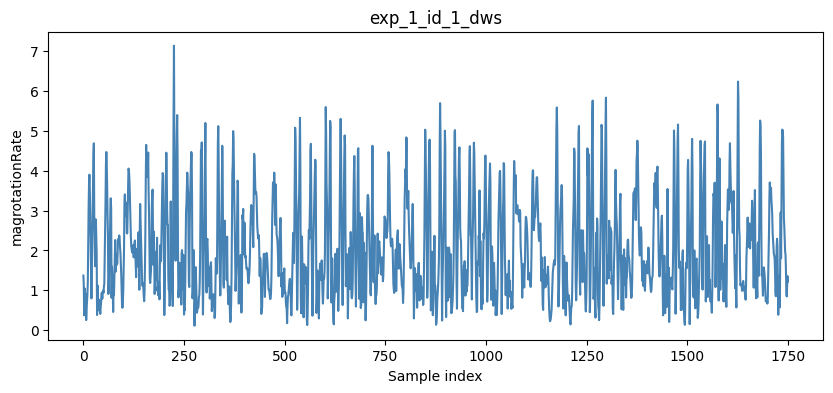

In [6]:
# 예시 시퀀스 그리기
plt.figure(figsize=(10, 4))
plt.plot(example['magrotationRate'].to_numpy(), color='steelblue')
plt.xlabel('Sample index')
plt.ylabel('magrotationRate')
plt.title(str(example_info['sequence_key']))
plt.show()


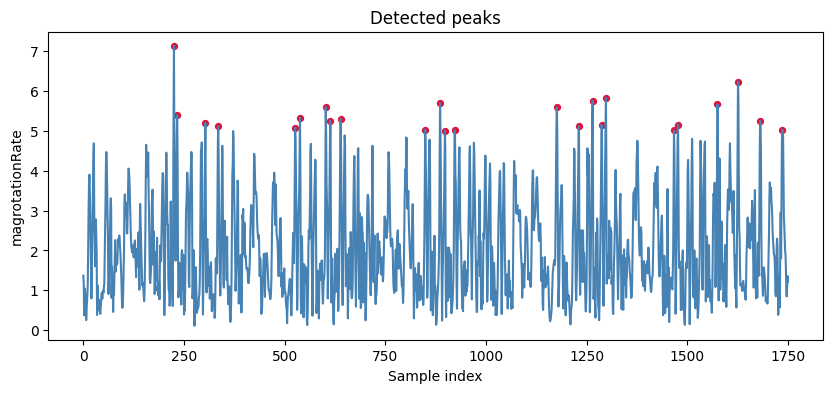

,peak_height,peak_index
0,7.138682,225
21,6.239476,1626
17,5.835136,1298
15,5.761030,1265
10,5.696929,886


In [7]:
# 예시 시퀀스 피크 표시
example_peaks = peak_table(example['magrotationRate'], threshold=5.0)

plt.figure(figsize=(10, 4))
plt.plot(example['magrotationRate'].to_numpy(), color='steelblue')
plt.scatter(example_peaks['peak_index'], example_peaks['peak_height'], color='crimson', s=18)
plt.xlabel('Sample index')
plt.ylabel('magrotationRate')
plt.title('Detected peaks')
plt.show()

example_peaks.head()


In [8]:
# 분류용 데이터 준비
feature_cols = [
    'f_n', 'p_interval', 'p_interval_std',
    'p_mean', 'p_max', 'p_min', 'p_std',
    'cfR', 'cfA',
]

X = peak_final[feature_cols].fillna(0.0)
y = peak_final['activity']

model = RandomForestClassifier(n_estimators=300, random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

metrics = pd.DataFrame(
    {
        'metric': ['cv_accuracy_mean', 'cv_accuracy_std', 'num_sequences', 'num_features'],
        'value': [accuracy.mean(), accuracy.std(ddof=1), len(peak_final), len(feature_cols)],
    }
)

print('mean accuracy:', round(accuracy.mean(), 6))
print('std:', round(accuracy.std(ddof=1), 6))
metrics


mean accuracy: 0.663889
std: 0.087303


,metric,value
0,cv_accuracy_mean,0.663889
1,cv_accuracy_std,0.087303
2,num_sequences,360.000000
3,num_features,9.000000


In [9]:
# 연습문제: 통계 특징 + 피크 특징 결합
stats_final = (
    har_total.groupby(['exp_no', 'id', 'activity'], sort=True)
    .agg(
        rr_mean=('magrotationRate', 'mean'),
        rr_min=('magrotationRate', 'min'),
        rr_max=('magrotationRate', 'max'),
        rr_std=('magrotationRate', 'std'),
        rr_skew=('magrotationRate', 'skew'),
        acc_mean=('maguserAcceleration', 'mean'),
        acc_min=('maguserAcceleration', 'min'),
        acc_max=('maguserAcceleration', 'max'),
        acc_std=('maguserAcceleration', 'std'),
        acc_skew=('maguserAcceleration', 'skew'),
    )
    .reset_index()
)

combined_final = peak_final.merge(
    stats_final,
    on=['exp_no', 'id', 'activity'],
    how='left',
)

stat_feature_cols = [
    'rr_mean', 'rr_min', 'rr_max', 'rr_std', 'rr_skew',
    'acc_mean', 'acc_min', 'acc_max', 'acc_std', 'acc_skew',
]
combined_feature_cols = feature_cols + stat_feature_cols

baseline_accuracy = accuracy.copy()
combined_accuracy = cross_val_score(
    model,
    combined_final[combined_feature_cols].fillna(0.0),
    combined_final['activity'],
    cv=cv,
    scoring='accuracy',
)

comparison = pd.DataFrame(
    {
        'setting': ['peak_only', 'peak_plus_stats'],
        'cv_accuracy_mean': [baseline_accuracy.mean(), combined_accuracy.mean()],
        'cv_accuracy_std': [baseline_accuracy.std(ddof=1), combined_accuracy.std(ddof=1)],
        'num_features': [len(feature_cols), len(combined_feature_cols)],
        'improvement_vs_peak': [0.0, combined_accuracy.mean() - baseline_accuracy.mean()],
    }
)

print('peak only mean accuracy:', round(baseline_accuracy.mean(), 6))
print('peak + stats mean accuracy:', round(combined_accuracy.mean(), 6))
print('improvement:', round(combined_accuracy.mean() - baseline_accuracy.mean(), 6))
comparison


peak only mean accuracy: 0.663889
peak + stats mean accuracy: 0.855556
improvement: 0.191667


,setting,cv_accuracy_mean,cv_accuracy_std,num_features,improvement_vs_peak
0,peak_only,0.663889,0.087303,9,0.000000
1,peak_plus_stats,0.855556,0.074994,19,0.191667
